# 🎓 **CS331 <span style="color:#008080;"> PA 2 Part 1 — Predicting Car Fuel Efficiency with Linear Regression</span>**  

In this assignment, you’ll put your Machine Learning to test and build a <span style="color:#008080;">Linear Regression model</span> to find out what is making your car use so much fuel! Your task is to use **relevant selected car features** such as <span style="color:#f4a261;">engine horsepower</span> or the <span style="color:#6baed6;">car’s weight</span> to predict **MPG (miles per gallon)** — turning engine specs and car stats into _knobs_ (class reference, iykyk).

### General instructions
* Follow along with the notebook, filling out the necessary code where instructed.
*   Use separate training and testing data.
* <span style="color: red;">Make sure to run all cells for credit.</span>
* <span style="color: red;">Do not remove any pre-written code.</span> 
* <span style="color: red;">You must attempt all parts.</span> Do not assume that because something is for 0 marks, you can leave it - it will definitely be used in later parts.
* <span style="color: red;">Do not use unauthorized libraries.</span> You are not allowed to use `sklearn` for anything except train-test split.

**Allowed Libraries:**
*   Section 1 (from scratch): only `numpy`, `scipy`, `pandas`, `matplotlib`. You may only use `sklearn.model_selection.train_test_split` in this section; no other scikit-learn.
*   Section 2: you must use scikit-learn (details later).

## Auto MPG Dataset
This dataset provides characteristics of various cars from different model years and manufacturers, focusing on performance, design, and efficiency. The dataset contains 398 entries, each representing a car model, with features that correlate with a continuous Miles Per Gallon (MPG) score, which is the primary target variable.
The dataset was collected during the late 1970s and early 1980s, a time when fuel efficiency became a critical concern due to global oil crises.

**Features**



*  <span style="color:#6baed6;">MPG (miles per gallon):</span> A continuous variable representing the fuel efficiency of the car. This is the main target feature, with higher values indicating better efficiency.
* <span style="color:#6baed6;">Cylinders:</span> The number of cylinders in the engine. Cars with more cylinders tend to have higher power but lower fuel efficiency.  
*  <span style="color:#6baed6;">Displacement (cu in):</span> Engine displacement measured in cubic inches. Larger displacement generally indicates a more powerful engine but reduced MPG.
*  <span style="color:#6baed6;">Horsepower:</span> Engine power measured in horsepower. Higher horsepower can increase performance but often reduces fuel efficiency.
*  <span style="color:#6baed6;">Weight (lbs):</span> The weight of the car in pounds. Heavier cars usually consume more fuel, leading to lower MPG.
*  <span style="color:#6baed6;">Acceleration (0–60 mph in seconds):</span> The time taken for the car to accelerate from 0 to 60 miles per hour. Cars with lower acceleration times are faster but may sacrifice efficiency.


Start by importing the required libraries:

In [133]:
# Allowed everywhere
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# For 3D plots
from mpl_toolkits.mplot3d import Axes3D

DATA_PATH = "auto-mpg.csv"  # change if needed

# **Section 1**: Implementation from Scratch (70 Marks)
## 1. (EDA: Exploratory Data Analysis) (10 Marks)

### A. Data Loading & Cleaning
- Load the dataset into a pandas DataFrame.
- Convert the `"horsepower"` column to numeric (`pd.to_numeric(..., errors='coerce')`) so that `"?"` entries become `NaN`.
- Handle missing values (either drop rows with `NaN` or impute using mean/median).
- Keep only the relevant numeric columns for analysis.

### B. Scatter Plots
Create scatter plots of `mpg` vs:
- `weight`
- `horsepower`
- `displacement`
- `acceleration`
- `cylinders`
- `model year`

Each plot helps visualize how fuel efficiency (mpg) changes with respect to other variables.


### C. Feature Selection (3 features for modeling)


(398, 5)

    mpg  cylinders  displacement  horsepower  weight
0  18.0          8         307.0       130.0    3504
1  15.0          8         350.0       165.0    3693
2  18.0          8         318.0       150.0    3436
3  16.0          8         304.0       150.0    3433
4  17.0          8         302.0       140.0    3449

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 15.7 KB
None


C:\Users\Muhammad Bilal\AppData\Local\Temp\ipykernel_30896\4118079185.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].median(), inplace=True) #fillna fills in the missing Values and inplace is used to make direct changes into df without making a copy


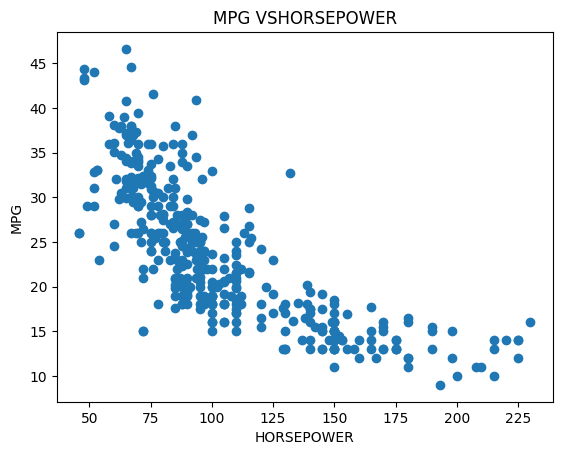

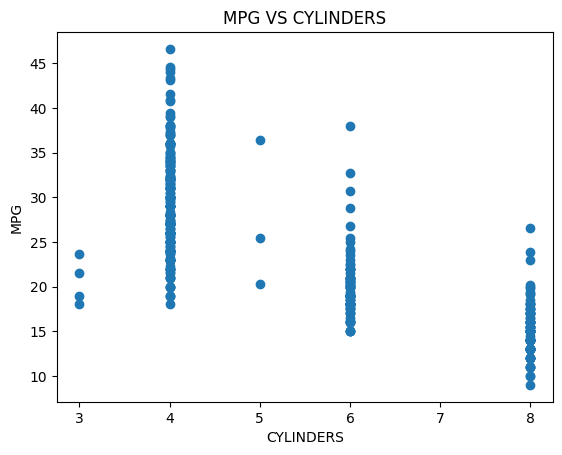

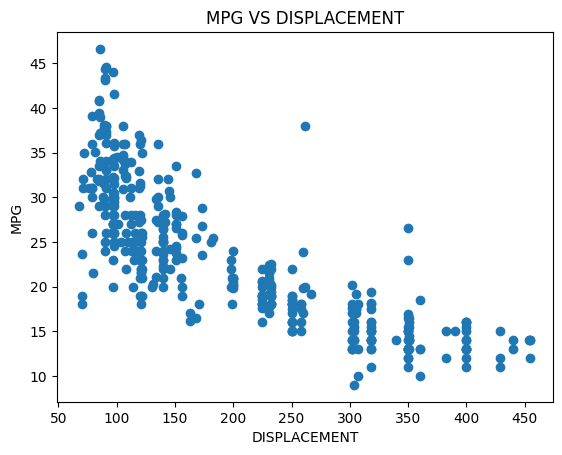

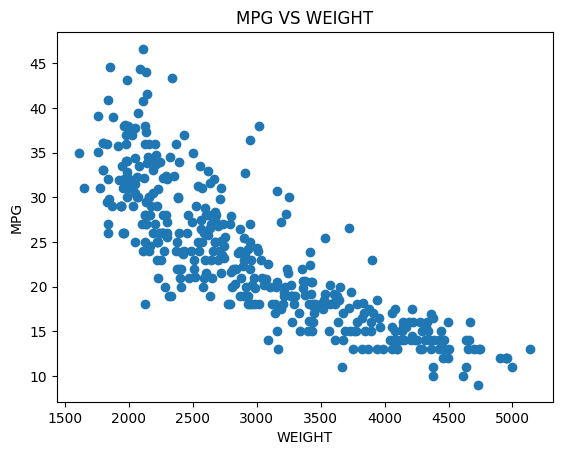

Chosen features: ['horsepower', 'displacement', 'weight']


In [134]:
# TODO: Load & clean
df = pd.read_csv('auto-mpg.csv')
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce') #coerce is used to substitute any missin valye ny NAN
df['horsepower'].fillna(df['horsepower'].median(), inplace=True) #fillna fills in the missing Values and inplace is used to make direct changes into df without making a copy
print(df.shape) 
print()
print(df.head())
print()
print(df.info())
# TODO: Scatter plots of mpg vs candidate features
plt.scatter(df['horsepower'],df['mpg'])
plt.ylabel("MPG")
plt.xlabel("HORSEPOWER")
plt.title("MPG VSHORSEPOWER")
plt.show()

plt.scatter(df['cylinders'],df['mpg'])
plt.ylabel("MPG")
plt.xlabel("CYLINDERS")
plt.title("MPG VS CYLINDERS")
plt.show()

plt.scatter(df['displacement'],df['mpg'])
plt.ylabel("MPG")
plt.xlabel("DISPLACEMENT")
plt.title("MPG VS DISPLACEMENT")
plt.show()

plt.scatter(df['weight'],df['mpg'])
plt.ylabel("MPG")
plt.xlabel("WEIGHT")
plt.title("MPG VS WEIGHT")
plt.show()
# TODO: Choose your three features based on EDA
features = ['horsepower','displacement','weight']  # edit after EDA
print("Chosen features:", features)

## 2. Normalizing Data (10 Marks)

### Why Standardization?
Standardization (z-score normalization) transforms each feature so that:
- Mean = 0  
- Standard Deviation = 1  

This ensures:
- Gradient descent is more stable and converges faster.  
- Features measured on different scales (e.g., horsepower vs. weight) become comparable.  
- Regularization (L1/L2 penalties) treats features fairly instead of being dominated by large-scale features.  

### Implementation

We implement a custom **StandardScaler** class with two methods:

#### A. `fit(X)`
- Compute the mean and standard deviation **only on the training set**.  
- Store these values for later use.  

#### B. `transform(X)`
- Use the stored training statistics to normalize each feature.  
- This means: for every feature, subtract its training mean and divide by its training standard deviation.  
- In this way, all features are rescaled to have mean 0 and standard deviation.

In [135]:
import numpy as np

class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        """
        Compute mean and std for each feature (column).
        Only use training data!
        """
        self.mean = np.mean(X,axis = 0)
        self.std = np.std(X, axis = 0)

    def transform(self, X):
        """
        Standardize data using stored mean and std.
        """
        return (X- self.mean) / self.std
        

## 3. Train/Test Split and Standardize (5 Marks)

### Train/Test Split (60/40)
We split the dataset into two parts:
- **60% training data** → used to fit the model and scaler.  
- **40% test data** → held out for final evaluation.  

This is done with a single call to `train_test_split`.

To ensure all features are on the same scale:
- We **fit the scaler only on the training set** (compute mean and std).  
- Then we apply the same transformation to the test set.  



In [136]:
# assumes: df (your data DataFrame), features (list of exactly 3 chosen feature names)
X_raw = df[features].to_numpy(dtype=float)
y     = df['mpg'].to_numpy(dtype=float).reshape(-1, 1)
print(df.head())

# TODO
X_train, X_test, Y_train, Y_test = train_test_split(X_raw,y, test_size= 0.4 ,random_state= 42)
scaler = StandardScaler()
scaler.fit(X_train)
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)
print(X_train.shape)
print(scaled_X_train.shape)
print(Y_train.shape)

    mpg  cylinders  displacement  horsepower  weight
0  18.0          8         307.0       130.0    3504
1  15.0          8         350.0       165.0    3693
2  18.0          8         318.0       150.0    3436
3  16.0          8         304.0       150.0    3433
4  17.0          8         302.0       140.0    3449
(238, 3)
(238, 3)
(238, 1)


### 3D Scatter Plot (Training Set)
Finally, we plot the **standardized training features** in a 3D scatter plot:  
- The three axes correspond to the three selected features.  
- Each point represents a car in the dataset.  
- Points are **colored by mpg**, so we can visually inspect how fuel efficiency changes across feature space.  

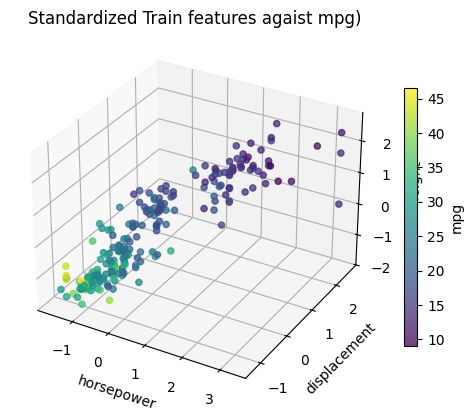

In [137]:
# --- 3D scatter of TRAIN (standardized) ---
# Assumes variables (change names if you used different ones):
# X_train_std: standardized training data
# y_train: y labels of training data

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(
    scaled_X_train[:, 0], scaled_X_train[:, 1], scaled_X_train[:, 2],
    c=Y_train.ravel(), alpha=0.75
)

ax.set_xlabel(features[0])
ax.set_ylabel(features[1])
ax.set_zlabel(features[2])
ax.set_title("Standardized Train features agaist mpg)")

fig.colorbar(p, shrink=0.7, label="mpg")
plt.show()

## 4. Linear Regression Model (40 Marks)

**Notation (shapes)**
- Let $m$ = #examples, $d$ = #features (**here $d=3$**).
- $X \in \mathbb{R}^{m\times d}$: standardized features (from `StandardScaler`).
- $\tilde{X} = [\mathbf{1} \mid X] \in \mathbb{R}^{m\times(d+1)}$: features **with a bias column** of 1s.
- $\theta \in \mathbb{R}^{(d+1)\times 1}$: parameters (first entry is the bias).
- $y \in \mathbb{R}^{m\times 1}$: targets (mpg).



**Hypothesis (prediction)**

$$
\hat{y} = \tilde{X}\,\theta
$$

Equivalently (separating bias and weights):

$$
\hat{y} = X\,w + b \quad\text{with}\quad \theta = \begin{bmatrix} b \\[2pt] w \end{bmatrix}.
$$



**Loss (MSE with 1/2)**

$$
J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\big(\hat y^{(i)} - y^{(i)}\big)^2
= \frac{1}{2m}\,\lVert \tilde{X}\theta - y \rVert_2^2
$$



**Gradient**

Let $r=\tilde{X}\theta - y$. Then

$$
\nabla_{\theta} J(\theta) = \frac{1}{m}\,\tilde{X}^\top(\tilde{X}\theta - y).
$$



**Batch Gradient Descent (BGD) update**

$$
\theta \leftarrow \theta \;-\; \alpha \cdot \frac{1}{m}\,\tilde{X}^\top(\tilde{X}\theta - y).
$$



Now that your data is ready, you should implement the gradient descent algorithm inside a class `LinearRegression`. The class should include the following methods:

- `__init__`: The constructor of the class. Set up the learning rate, convergence tolerance, random seed, and prepare variables to store weights, bias, gradients, and cost history.

- `initialize_parameters`: Initialize the model parameters (weights and bias) before training begins.

- `forward`: Take the input features and compute the predictions of the model.

- `compute_cost`: Compute the cost function using Mean Squared Error with a 1/2 factor. This value should be saved after each iteration.

- `backward`: Calculate the gradients of the cost function with respect to the weights and bias using the training data.

- `fit`: Train the model by running gradient descent for a fixed number of iterations (or until convergence). In each iteration call `forward`, `compute_cost`, `backward`, and then update the parameters. Also, keep track of the cost values and optionally plot them at the end.

- `predict`: Use the learned parameters to predict the output for new input data.

- `score` : Evaluate model performance on test data by returning a metric such as MSE.

**Deliverables**  
- Plot the training cost curve (MSE/2) against the number of iterations. 
- Report model performance on both train and test data (MSE).  


In [138]:
class LinearRegression:
    def __init__(self, n_features, learning_rate=0.01, seed=42):
        """
        Parameters:
            n_features (int): Number of features (columns) in the input data.
            learning_rate (float): Step size for gradient descent updates.
            seed (int): Random seed for reproducible weight initialization.
        """
        self.features = n_features
        self.learning_rate = learning_rate
        np.random.seed(seed)
        self.weights=np.random.randn(n_features,1)
        self.cost_history = []
        self.bias = 0.0

    def forward(self, X):
        """
        Parameters:
            X (numpy.ndarray): Input data of shape (m, n_features).

        Returns:
            numpy.ndarray: Predictions of shape (m,).
        """
        pred = []
        for i,sample in enumerate(X):
            pred.append(np.dot(sample,self.weights) + self.bias)
        return np.array(pred)
        # print(pred.shape)

    def compute_cost(self, predictions):
        """
        Parameters:
            predictions (numpy.ndarray): Predictions of shape (m,).

        Returns:
            float: Mean squared error cost with 1/2 factor.
        """
        m = predictions.shape[0]
        cost = (1.0 / (2 * m)) * np.sum((predictions - self.y) ** 2)
        return cost

    def backward(self, predictions):
        """
        Parameters:
            predictions (numpy.ndarray): Predictions of shape (m,).

        Updates: 
            self.dW (numpy.ndarray): Gradient of weights, shape (n_features,).
            self.db (float): Gradient of bias.
        """
        m = len(predictions)
        self.dW = 1/m * np.dot(self.X.T , predictions - self.y)
        self.db = 1/m * np.sum(predictions-self.y)


    def fit(self, X, y, iterations, plot_cost=False):
        """
        Parameters:
            X (numpy.ndarray): Training input data of shape (m, n_features).
            y (numpy.ndarray): Training labels of shape (m,) or (m,1).
            iterations (int): Number of gradient descent steps.
            plot_cost (bool, optional): Whether to plot the cost after training.

        Returns:
            self: Trained LinearRegression model.
        """
        self.X = np.array(X)
        self.y = np.array(y).reshape(-1,1)

    
        for i in range(iterations):
            predictions = self.forward(X)
            cost = self.compute_cost(predictions)
            self.backward(predictions)
            
            self.weights -=  self.learning_rate *  self.dW
            self.bias -= self.learning_rate * self.db
            self.cost_history.append(cost)
        return self

    def predict(self, X):
        """
        Parameters:
            X (numpy.ndarray): Input data of shape (m, n_features).

        Returns:
            numpy.ndarray: Predictions of shape (m,).
        """
        return self.forward(X)
        



## 5. Evaluation (5 Marks)

After training your `LinearRegression` model, you should evaluate its performance:

1. **Plot the cost function**  
   - This shows how the cost (MSE/2) decreases over iterations.

2. **Report Mean Squared Error (MSE)**  
   - Compute and print the MSE for both the **training set** and the **test set**.  
   - This allows you to compare how well the model fits the training data and how well it generalizes to unseen data.

**Your train loss should be around 17.0 and test loss should be around 20.0**


Train Loss: 19.114769553602933
Test Loss: 17.747570661994104


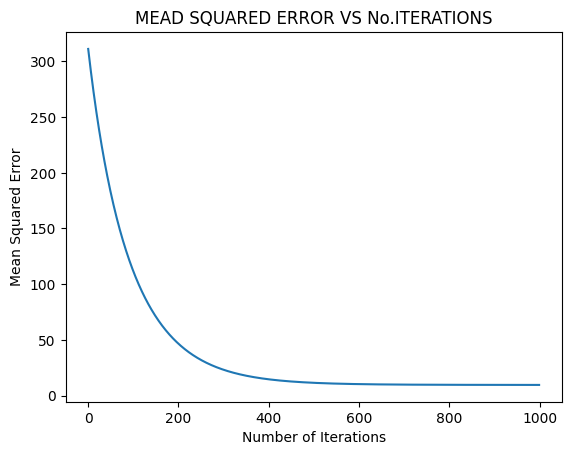

In [139]:
# Hyperparameters
n_epochs = 1000
alpha    = 0.005

# Train the model
lr = LinearRegression(n_features=3, learning_rate=alpha)
lr.fit(scaled_X_train,Y_train,n_epochs)
# Plot cost curve (MSE/2 from training)
plt.plot(lr.cost_history)
plt.xlabel("Number of Iterations")
plt.ylabel("Mean Squared Error")
plt.title("MEAD SQUARED ERROR VS No.ITERATIONS")
# Evaluate on train data
train_pred = lr.predict(scaled_X_train)
# Evaluate on test data
test_pred = lr.predict(scaled_X_test)
# Print results
train_loss = np.mean((train_pred- Y_train) ** 2)
test_loss = np.mean((test_pred - Y_test) ** 2)
print("Train Loss: {0}".format(train_loss))
print("Test Loss: {0}". format(test_loss))


### Print the Learnt Model Weights 
Print the bias and model weights, we will use these for comparison later.

In [140]:
print("Learned weights (W):", lr.weights)
print("Learned bias (b):", lr.bias)

Learned weights (W): [[-1.65701145]
 [-2.38729324]
 [-2.85486196]]
Learned bias (b): 23.19671669509482


### Visualizing the Learnt Function - Another 3D Scatter plot
We will now plot the **learnt function** on the **standardized training features** in a 3D scatter plot. This is similar to the earlier feature plot we made, except we now superpose our learnt function on it. 
- The three axes correspond to the three selected features.  
- Each point represents a car in the dataset.  
- Points are **colored by mpg**, so we can visually inspect how fuel efficiency changes across feature space.  
- We see **diffused points** all across the 3D space now - their colors represent the mpg value your model **predicts** for that combination of the three features. So while we initially had a few real data points against their real mpg value, we now have a function that produces an mpg value against every possible data point (a data point being a specific combination of the features). This means that we have discovered or at least estimated the underlying unknown probability function itself that gives rise to the data - **that's the magical power of regression**!
- Your model is great if the predicted colors match the colors of the real data points in each region.

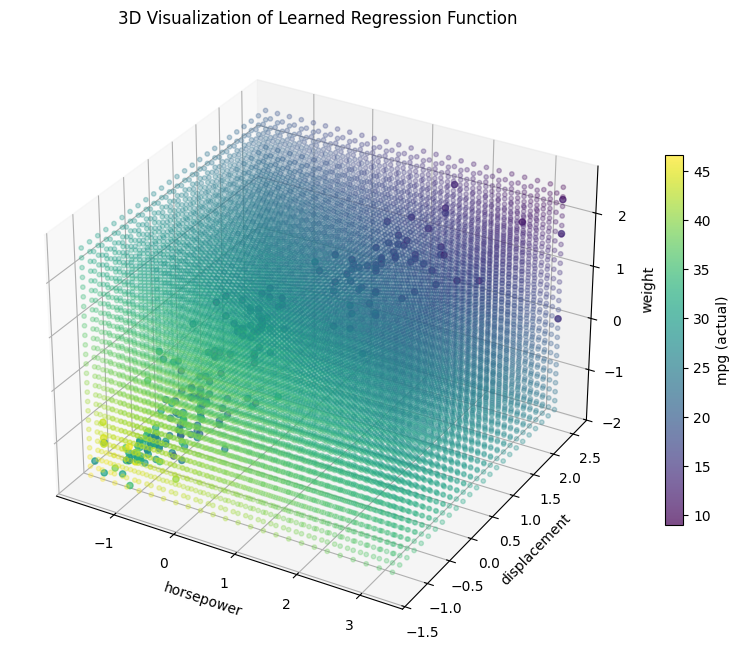

In [141]:
# Define feature ranges — smaller grid for fewer predicted points

# Variables (change names if you used different ones):
# scaled_X_train: standardized training data
# y_train: y labels of training data

x_range = np.linspace(scaled_X_train[:, 0].min(), scaled_X_train[:, 0].max(), 25)
y_range = np.linspace(scaled_X_train[:, 1].min(), scaled_X_train[:, 1].max(), 25)
z_range = np.linspace(scaled_X_train[:, 2].min(), scaled_X_train[:, 2].max(), 25)

# Create 3D grid for predictions
x_surf, y_surf, z_surf = np.meshgrid(x_range, y_range, z_range)
points = np.c_[x_surf.ravel(), y_surf.ravel(), z_surf.ravel()]
predicted = lr.predict(points).reshape(x_surf.shape)

# === Plot ===
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter all actual training data
p = ax.scatter(
    scaled_X_train[:, 0], scaled_X_train[:, 1], scaled_X_train[:, 2],
    c=Y_train.ravel(), cmap='viridis', alpha=0.7, label='Training data'
)

# Overlay sparse model predictions
ax.scatter(
    x_surf.ravel(), y_surf.ravel(), z_surf.ravel(),
    c=predicted.ravel(), cmap='viridis', alpha=0.3, s=10, label='Model predictions'
)

# Axis labels and title
ax.set_xlabel(features[0])
ax.set_ylabel(features[1])
ax.set_zlabel(features[2])
ax.set_title('3D Visualization of Learned Regression Function')

# Colorbar on same scale as mpg
fig.colorbar(p, ax=ax, label='mpg (actual)', shrink=0.6)

plt.show()


# **Section 2** (30 Marks)

## Linear Regression using Scikit-learn (15 Marks)
We first fit an **Ordinary Least Squares (OLS)** linear regression model using `sklearn.LinearRegression`.  
The model is trained on the standardized training data, and the Mean Squared Error (MSE/2) is reported for both training and test sets.



In [142]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

# Train Linear Regression model
sk_model = LinearRegression()
sk_model.fit(scaled_X_train,Y_train)
# Predictions
pred_train = sk_model.predict(scaled_X_train)
pred_test = sk_model.predict(scaled_X_test)

# Mean Squared Error
train_mse = mean_squared_error(pred_train,Y_train)
test_mse = mean_squared_error(pred_test,Y_test)

print("Trained data error from sklearn model: {0}".format(train_mse))
print("Test data error from sklearn model: {0}".format(test_mse))


Trained data error from sklearn model: 18.813206301903854
Test data error from sklearn model: 17.211432719217132


## Ridge Regression (5 Marks)

Next, we apply **Ridge Regression** (L2 regularization).  
Use the `mean_squared_error` to find loss and print it. Also plot the regularization coefficients alpha (x-axis) with learned parameters $\theta$  (y-axis) for Ridge.

Ridge Model Training Data Error: 18.81434183926983
Ridge Model Testing Data Error: 17.21468377582361


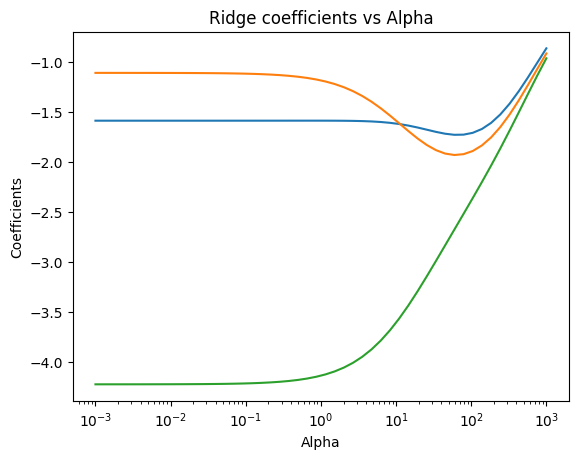

In [143]:
ridge_model = Ridge()
ridge_model.fit(scaled_X_train,Y_train)

train_pred = ridge_model.predict(scaled_X_train)
test_pred = ridge_model.predict(scaled_X_test)

train_mse = mean_squared_error(train_pred,Y_train)
test_mse = mean_squared_error(test_pred,Y_test)

print("Ridge Model Training Data Error: {0}".format(train_mse))
print("Ridge Model Testing Data Error: {0}".format(test_mse))

alphas = np.logspace(-3, 3, 50)
coefficients = []

for a in alphas:
    ridge_model = Ridge(alpha=a)
    ridge_model.fit(scaled_X_train, Y_train)
    coefficients.append(ridge_model.coef_)

plt.plot(alphas, coefficients)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Ridge coefficients vs Alpha')
plt.show()


## Lasso Regression (5 Marks)

Finally, we apply **Lasso Regression** (L1 regularization).  

Use the `mean_squared_error` to find loss and print it. Also plot the regularization coefficients alpha (x-axis) with learned parameters $\theta$  (y-axis) for Lasso.

Lasso Model Training Data Error: 19.904933345484356
Lasso Model Testing Data Error: 16.522749720142592


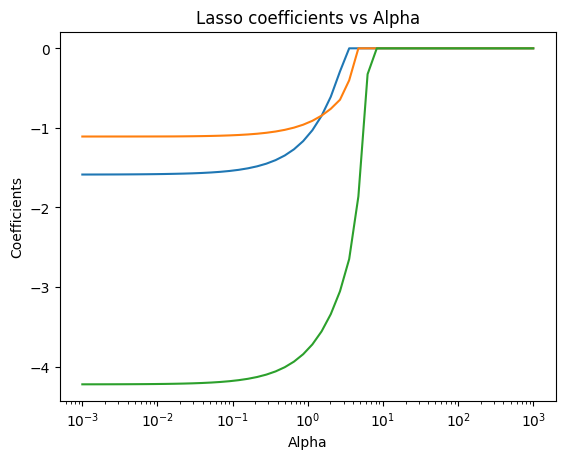

In [144]:
lasso_model = Lasso()
lasso_model.fit(scaled_X_train,Y_train)

train_pred = lasso_model.predict(scaled_X_train)
test_pred = lasso_model.predict(scaled_X_test)

train_mse = mean_squared_error(train_pred,Y_train)
test_mse = mean_squared_error(test_pred,Y_test)

print("Lasso Model Training Data Error: {0}".format(train_mse))
print("Lasso Model Testing Data Error: {0}".format(test_mse))

alphas = np.logspace(-3, 3, 50)
coefficients = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(scaled_X_train, Y_train)
    coefficients.append(lasso_model.coef_)

plt.plot(alphas, coefficients)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Lasso coefficients vs Alpha')
plt.show()

## Comparison on Coefficients - Regularized vs. Non-Regularized (5 Marks)
a) Explain what the Ridge and Lasso parameter graphs show. 

b) Briefly discuss the difference between the model coefficients (weights) of your initial model and the regularized models. How and why are they different?

#### Answer Here:
(a) The Ridge Parameter Graph implies that as alpha increases the coeffecients/parameters gradually start approaching 0. This graph never truly become equal to zero and there magnitude is decreased smoothly . While in the lasso graph, as alpha increases, all of the coefficient dip down to 0 causing some features to get entirely eliminated .Both of these methods put a constraint on the coefficients by limiting there maximum value .

(b) In Our Initial, Normal Linear Ragression model we could see that the growth of our coefficents was boundless and had no upper limit which in turn can lead to Overfitting .But the regularized models implement that limit to prevent overfitting with the traning data and allow better generalisation. It heps keep the coefficients smaller,stable and less prone to fitting with the noise.
